C:\Users\miran\AppData\Local\Temp\ipykernel_59488\561394389.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_efficiency.values, y=dept_efficiency.index, ax=axes[0, 0], palette='Greens_r')
C:\Users\miran\AppData\Local\Temp\ipykernel_59488\561394389.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='지역', y='만족도', data=df, ax=axes[0, 1], palette='Pastel1')


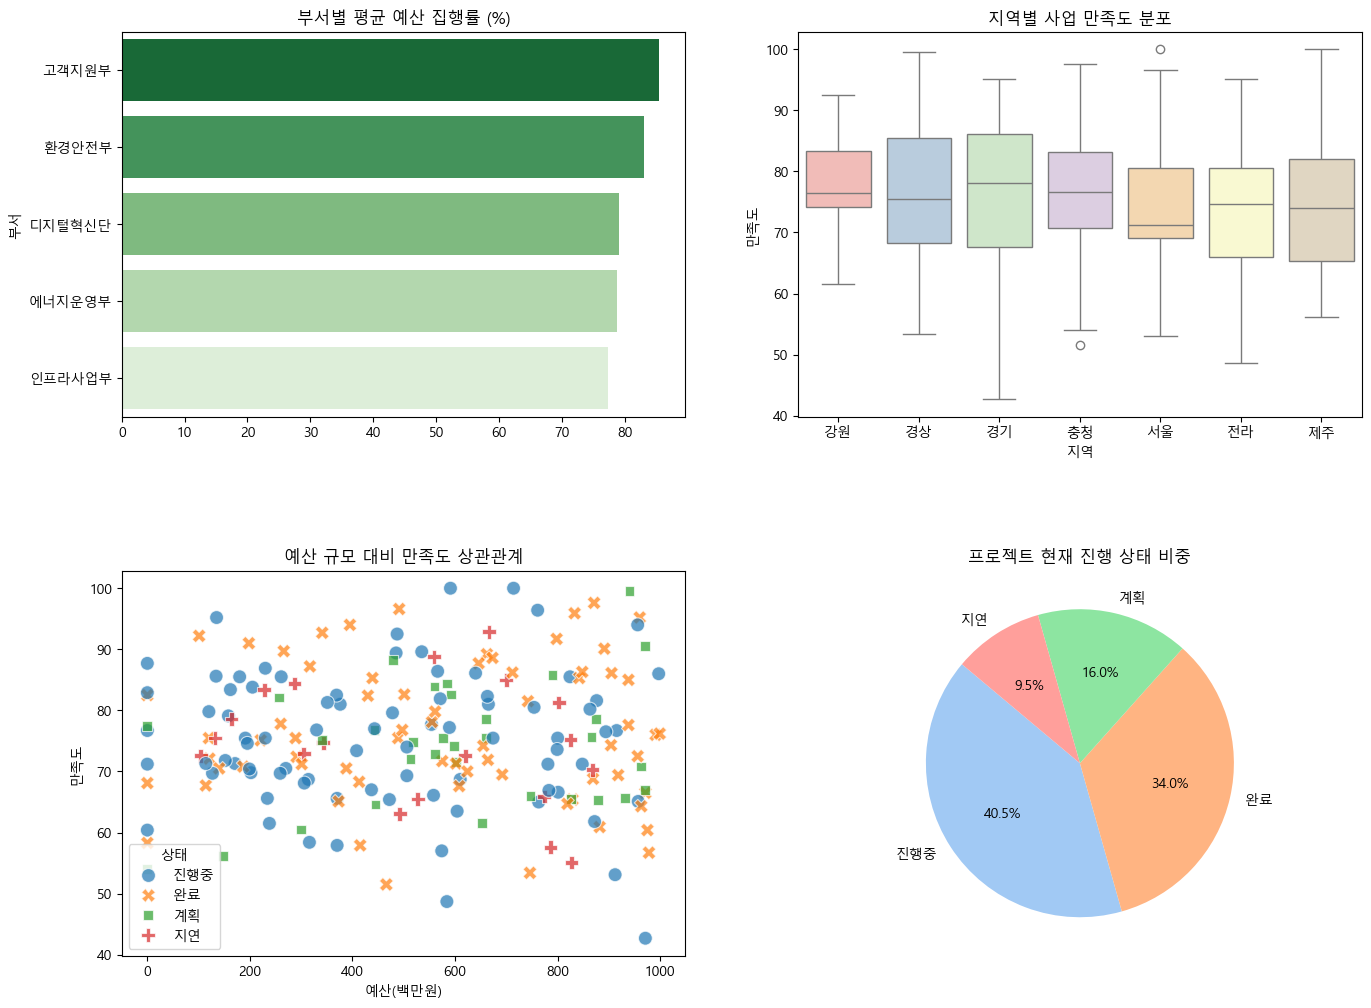

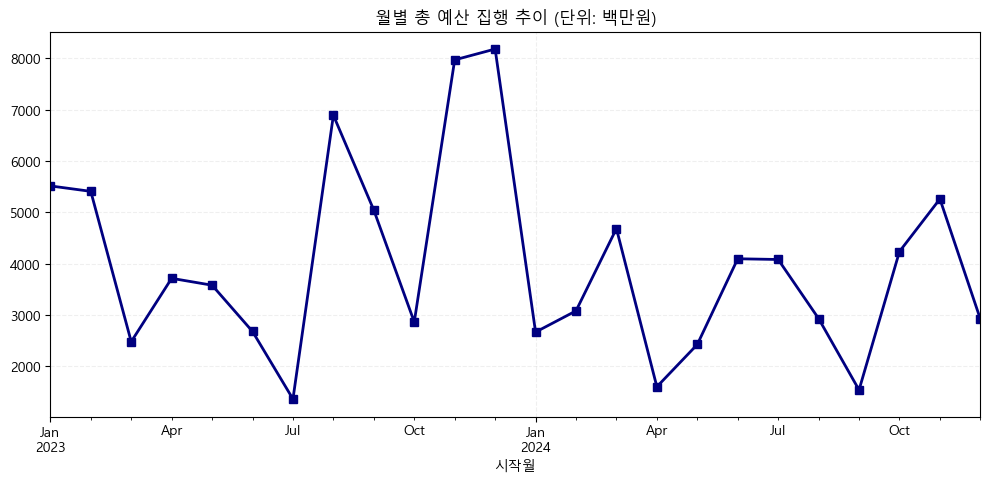

In [ ]:
# 데이터 가공
# 배운 걸 모아서 보고서 한 장으로 (전문가가 만든 완성본)
# axes[0, 0], axes[1, 1] 이런 좌표 개념

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 환경 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기 [파일 공유_깃허브_200행]
df = pd.read_excel('public_business_data.xlsx')

# 2. 데이터 전처리 (민원 대신 집행률에 집중)
df['만족도'] = df['만족도'].fillna(df['만족도'].mean()) #fillna빈칸
df['예산(백만원)'] = df['예산(백만원)'].fillna(0)
# 집행률 계산 (럼 0으로 나눌 때 발생하는 수학적 오류를 잡아주는 실무 코드)
df['집행률'] = (df['집행액(백만원)'] / df['예산(백만원)'] * 100).replace([np.inf, -np.inf], 0).fillna(0)
df['시작월'] = df['시작일'].dt.to_period('M') #날짜를 월 단위로 묶는 고급 기법

# 3. 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# (1) 막대 그래프: 부서별 평균 집행률 (사업 운영의 효율성 확인)
dept_efficiency = df.groupby('부서')['집행률'].mean().sort_values(ascending=False)
sns.barplot(x=dept_efficiency.values, y=dept_efficiency.index, ax=axes[0, 0], palette='Greens_r')
axes[0, 0].set_title('부서별 평균 예산 집행률 (%)')

# (2) 박스 플롯: 지역별 만족도 분포 (어느 지역에서 성과가 일관적인가?)
sns.boxplot(x='지역', y='만족도', data=df, ax=axes[0, 1], palette='Pastel1')
axes[0, 1].set_title('지역별 사업 만족도 분포')

# (3) 산점도: 예산 규모와 만족도의 관계 (돈을 많이 쓰면 만족도가 높은가?)
sns.scatterplot(x='예산(백만원)', y='만족도', hue='상태', style='상태', data=df, ax=axes[1, 0], s=100, alpha=0.7)
axes[1, 0].set_title('예산 규모 대비 만족도 상관관계')

# (4) 파이 차트: 상태별 프로젝트 비중
status_counts = df['상태'].value_counts()
axes[1, 1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('프로젝트 현재 진행 상태 비중')

plt.show()

# (5) 선 그래프: 월별 예산 집행 추이 (계절성 확인)
plt.figure(figsize=(12, 5))
monthly_spending = df.groupby('시작월')['집행액(백만원)'].sum()
monthly_spending.plot(kind='line', marker='s', color='navy', linewidth=2)
plt.title('월별 총 예산 집행 추이 (단위: 백만원)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

현실적인 상관관계: 데이터는 집행액이 예산에 가까울수록(집행률이 높을수록) 만족도가 높게 나오도록 설계. 산점도를 그렸을 때 우상향하는 패턴이 보여 **"데이터 간의 관계"**를 설명하기 좋음

 '집행률', '만족도', '지역별 분포' 등 성과 중심 지표로 

다양한 전처리 실습: 예산과 만족도에 일부러 빈칸(NaN)을 넣어두어, fillna()의 필요성을 직접 체험하게 했습니다.